# 📊 Models Development & Performance Analysis

In this notebook we experimented with two architectures: **ResNet50** and **EfficientNet-B4** to solve the **APTOS Diabetic Retinopathy Classification** problem.

The evaluation metric used is **Quadratic Weighted Kappa (QWK)**, which is the official competition metric and is well suited for **ordinal classification problems** where prediction distance matters.

---

### 1️⃣ ResNet50 Baseline

The first experiment used **ResNet50 pretrained on ImageNet** with minimal modifications.

**Configuration**

- Resolution: `224 × 224`
- Transfer learning
- Standard classifier layer
- No strong augmentation

**Results**

Epoch 10/10  
Train Loss: 0.1205 | Train Acc: 0.9713 | Train QWK: 0.9823  
Val   Loss: 1.2603 | Val   Acc: 0.7926 | Val   QWK: 0.8563  

**Observation**

The model clearly **overfits the training data**.  
The large gap between training and validation metrics indicates poor generalization.

---

### 2️⃣ ResNet50 + Strong Augmentation + Dropout

To reduce overfitting, stronger regularization was introduced.

**Changes**

- Strong **Albumentations data augmentation**
- Added **Dropout layer** to the classifier
- Improved regularization

**Results**

Epoch 10/10  
Train Loss: 0.7125 | Train Acc: 0.7945 | Train QWK: 0.8567  
Val   Loss: 0.8896 | Val   Acc: 0.7872 | Val   QWK: 0.8693  

**Observation**

- Overfitting reduced significantly
- Training and validation metrics became closer
- Validation performance improved

This configuration became the **best ResNet setup**.

---

### 3️⃣ Increasing Image Resolution

To capture more fine-grained retinal features, image resolution was increased.

**Changes**

- Resolution increased to `320 × 320`
- Same augmentation pipeline

**Results**

Epoch 6/15  
Train Loss: 0.7713 | Train Acc: 0.7685 | Train QWK: 0.8662  
Val   Loss: 0.8569 | Val   Acc: 0.7708 | Val   QWK: 0.8541  

Early stopping triggered.

**Observation**

Higher resolution **did not improve ResNet performance**.

The best ResNet configuration remained:

`224 resolution + strong augmentation + dropout`

---

### 4️⃣ EfficientNet-B4 Baseline

Next we experimented with a stronger architecture: **EfficientNet-B4**.

**Configuration**

- Resolution: `380 × 380`
- Transfer learning
- Only classifier trained initially

**Results**

Epoch 12/12  
Train Loss: 0.9135 | Train Acc: 0.7231 | Train QWK: 0.8014  
Val   Loss: 0.9587 | Val   Acc: 0.7544 | Val   QWK: 0.8432  

**Observation**

Initial performance was lower than ResNet because the backbone had not yet been properly fine-tuned.

---

### 5️⃣ EfficientNet Fine-Tuning

To improve performance, deeper layers of EfficientNet were unfrozen.

**Changes**

- Reduced learning rate to `5e-5`
- Unfroze **3 EfficientNet blocks**
- Continued training with **CosineAnnealingLR scheduler**

**Results**

Epoch 20/20  
Train Loss: 0.7962 | Train Acc: 0.7545 | Train QWK: 0.8460  
Val   Loss: 0.9002 | Val   Acc: 0.7735 | Val   QWK: 0.8724  

**Observation**

After proper fine-tuning, **EfficientNet slightly outperformed ResNet**.

---

### 6️⃣ Threshold Optimization

Instead of using `argmax` directly, predictions were converted into **continuous severity scores**, and **threshold optimization** was applied to maximize QWK.

**Result**

QWK after threshold optimization ≈ **0.8905**

This step significantly improved performance **without retraining the model**.

---

### 7️⃣ Test Time Augmentation (TTA)

To further stabilize predictions, **Test Time Augmentation** was applied.

**Augmentations used**

- Original image
- Horizontal flip
- Vertical flip

**Result**

QWK with TTA ≈ **0.8918**

This produced a small but consistent improvement.

---

### 8️⃣ Model Ensemble

Finally, predictions from **ResNet50** and **EfficientNet-B4** were combined.

Instead of averaging class labels, we averaged **continuous severity scores** from both models.

**Result**

Final Ensemble QWK ≈ **0.8989**

---

### 🏆 Final Pipeline

The final prediction pipeline is:

Image  
↓  
Test Time Augmentation (TTA)  
↓  
ResNet50 Prediction  
EfficientNet-B4 Prediction  
↓  
Average Severity Scores  
↓  
Optimized Thresholds  
↓  
Final DR Class Prediction  

---

### 📈 Final Performance Summary

| Model Stage | QWK |
|-------------|------|
ResNet Baseline | 0.856 |
ResNet + Augmentation + Dropout | 0.869 |
EfficientNet Fine-Tuned | 0.872 |
Threshold Optimization | 0.890 |
Test Time Augmentation | 0.892 |
**ResNet + EfficientNet Ensemble** | **0.8989** |

---

This workflow demonstrates how **progressive experimentation, strong regularization, fine-tuning, threshold optimization, test-time augmentation, and ensembling** can significantly improve model performance for medical image classification tasks.

In [1]:
import os
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 🔍 Exploratory Data Analysis (EDA)

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/aptos2019-blindness-detection/train.csv")

print(train_df.head())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [4]:
print(train_df['diagnosis'].value_counts())

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


### The dataset is highly imbalanced, with class 0 dominating and severe cases underrepresented.

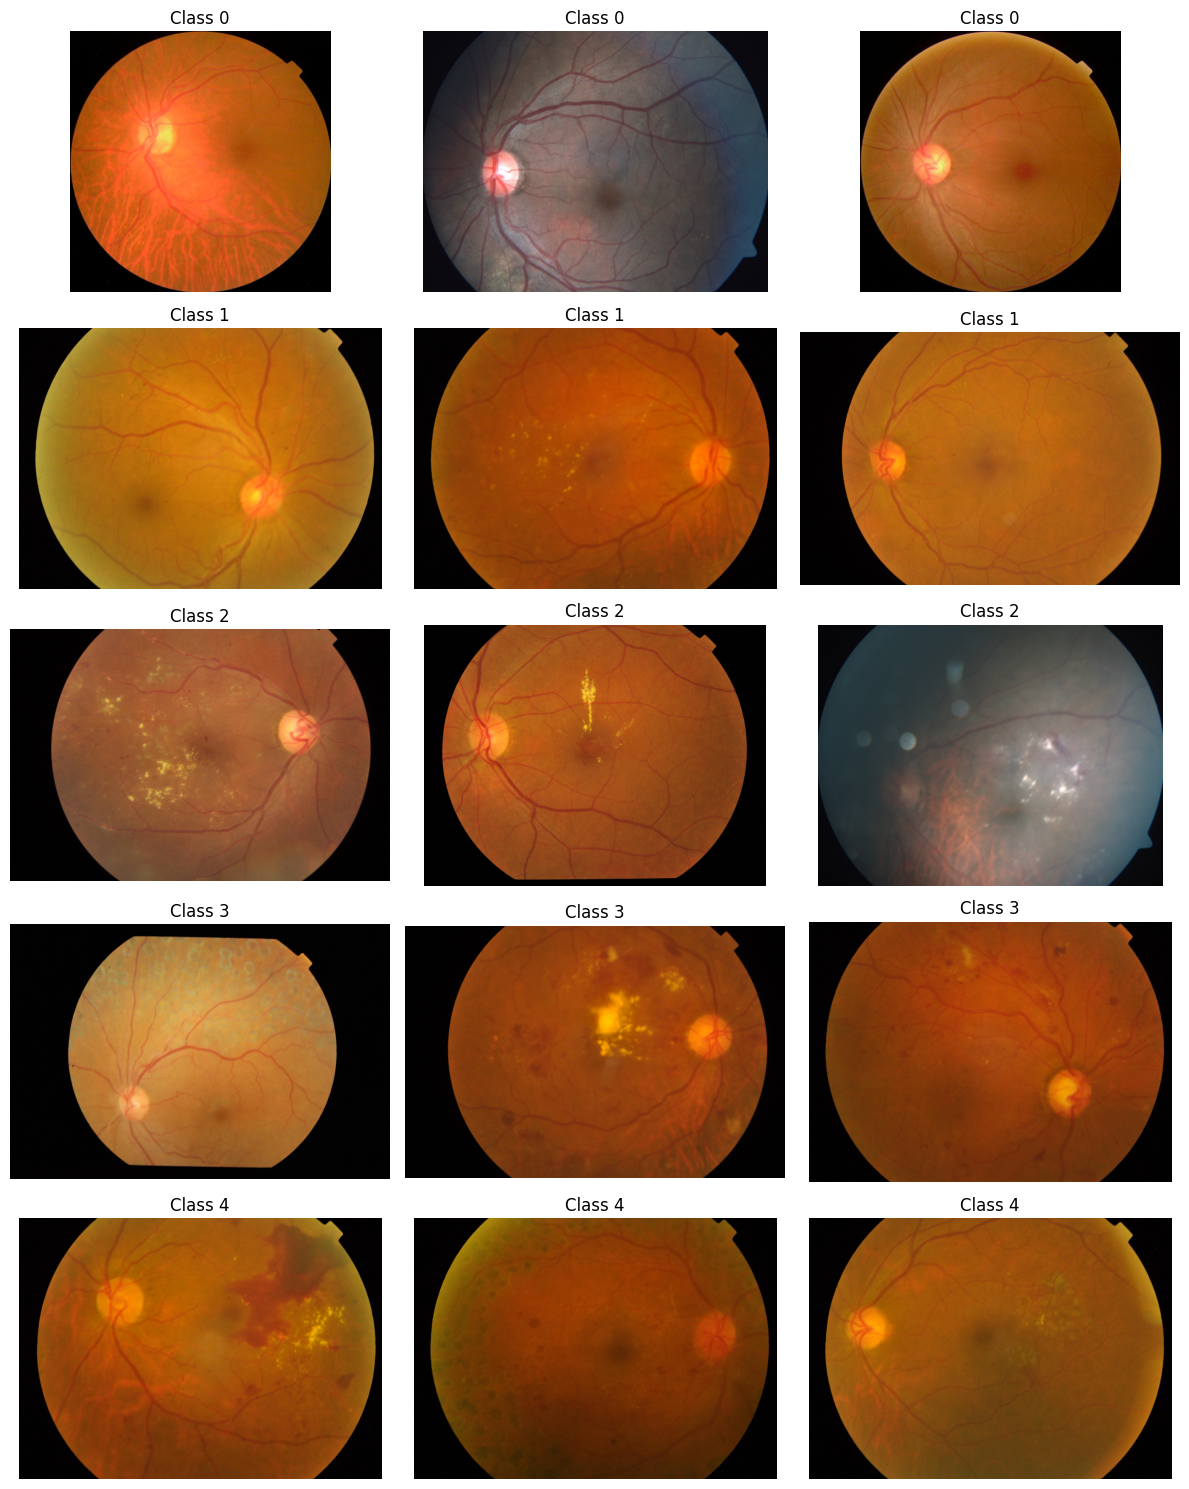

In [5]:
# path to images
IMAGE_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images"

classes = sorted(train_df['diagnosis'].unique())

fig, axes = plt.subplots(len(classes), 3, figsize=(12, 15))

for row, cls in enumerate(classes):
    
    # get 3 samples from this class
    samples = train_df[train_df['diagnosis'] == cls].sample(3)
    
    for col, (_, sample) in enumerate(samples.iterrows()):
        
        img_path = os.path.join(IMAGE_DIR, sample['id_code'] + ".png")
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(img)
        axes[row, col].set_title(f"Class {cls}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [6]:
sizes = []

for img_id in train_df['id_code'].sample(100):
    path = os.path.join(IMAGE_DIR, img_id + ".png")
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(2896, 1944), (2048, 1536), (3216, 2136), (2416, 1736), (2144, 1424), (819, 614), (2588, 1958), (1050, 1050), (4288, 2848), (1504, 1000), (3388, 2588), (1844, 1226)}


### Sampled images reveal highly variable resolutions, indicating the need for resizing to a consistent input size before training.

In [7]:
train_df["image_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".png")
)

train_df.head()

,id_code,diagnosis,image_path
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...


In [8]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["diagnosis"],
    random_state=42
)

### The dataset is split into training and validation sets using stratified sampling to preserve the original class distribution.

In [9]:
print(train_df["diagnosis"].value_counts())
print(val_df["diagnosis"].value_counts())

diagnosis
0    1444
2     799
1     296
4     236
3     154
Name: count, dtype: int64
diagnosis
0    361
2    200
1     74
4     59
3     39
Name: count, dtype: int64


In [10]:
!pip install albumentations

In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

## 🧪 Data Augmentation Strategy

To improve generalization and reduce overfitting observed in earlier experiments, we applied a **strong augmentation pipeline** using Albumentations.

### Why Strong Augmentation?

In initial experiments with weak or minimal augmentation, the model achieved very high training performance but failed to generalize well to validation data (clear overfitting).

To address this, we increased augmentation strength to:
- Expose the model to more diverse variations
- Improve robustness to real-world retinal image differences
- Reduce reliance on memorizing training samples

---

### Applied Transformations

- **Resize (380 × 380)**  
  Ensures a consistent input size while preserving sufficient detail for EfficientNet.

- **Horizontal & Vertical Flip**  
  Retinal images are orientation-invariant → safe and effective augmentation.

- **Shift / Scale / Rotate**  
  Simulates variations in camera positioning and zoom.

- **Brightness & Contrast Adjustment**  
  Mimics different lighting conditions during image acquisition.

- **Hue / Saturation / Value **  
  Accounts for color variability across devices and patients.

- **Blur / Sharpen (OneOf)**  
  Improves robustness to image quality differences.

- **Normalization (ImageNet stats)**  
  Aligns input distribution with pretrained backbone expectations.

- **Tensor Conversion**  
  Prepares data for PyTorch models.

---

### Impact

- Reduced overfitting significantly  
- Improved validation stability  
- Became a key factor in boosting QWK performance  

---

**Key Insight:**  
Strong augmentation is essential in medical imaging, where datasets are limited and variability in real-world conditions is high.

In [12]:
train_transforms = A.Compose([
    
    A.Resize(380,380), #(224,224) ,(320,320)

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.2,
        scale_limit=0.2,
        rotate_limit=180,
        border_mode=0,
        p=0.7
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.7
    ),

    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=20,
        p=0.5
    ),

    A.OneOf([
        A.GaussianBlur(blur_limit=3),
        A.Sharpen(),
    ], p=0.3),

    #A.Normalize(),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

In [13]:
val_transforms = A.Compose([
    A.Resize(380,380), #(224,224) ,(320,320)
    #A.Normalize(),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

In [14]:
class APTOSDataset(Dataset):
    
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["diagnosis"]
        
        #image = Image.open(img_path).convert("RGB")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image=image)["image"]
        
        return image, label

In [15]:
train_dataset = APTOSDataset(train_df, transform=train_transforms)
val_dataset = APTOSDataset(val_df, transform=val_transforms)

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32, #16
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32, #16
    shuffle=False,
    num_workers=2
)

### DataLoaders are used to efficiently load data in batches, with shuffling applied during training to improve generalization and disabled during validation for consistent evaluation.

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 380, 380])
torch.Size([32])


### ResNet

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 🧬 ResNet50 

In [19]:
import torchvision.models as models

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# replace final layer
num_features = model.fc.in_features
#model.fc = nn.Linear(num_features, 5)
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 5)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


### A pretrained ResNet50 model is used (transfer learning), with the final layer replaced by a custom classifier that includes **Dropout** for regularization and a **Linear layer** for 5-class prediction.

### Freeze backbone (Stage 1)

In [20]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

### All backbone layers are frozen while training only the final classifier (**feature extraction**) to leverage pretrained knowledge and reduce overfitting.

### Compute class weights

In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["diagnosis"]),
    y=train_df["diagnosis"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


### Class weights are computed using a balanced strategy to handle class imbalance, giving higher importance to underrepresented classes during training.

In [22]:
train_df['diagnosis'].value_counts()

diagnosis
0    1444
2     799
1     296
4     236
3     154
Name: count, dtype: int64

In [23]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(      
    model.fc.parameters(),
    lr=1e-3,   # lr for head
    weight_decay=1e-4
)   

### CrossEntropyLoss with **class weights** is used to address imbalance, while the **AdamW optimizer** updates only the classifier with weight decay for better generalization.

### train head

In [24]:
EPOCHS = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_preds = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)

    # STORE METRICS

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/5
Train Loss: 1.5397 | Train Acc: 0.4196
Val Loss: 1.2627 | Val Acc: 0.5730
----------------------------------------
Epoch 2/5
Train Loss: 1.3210 | Train Acc: 0.5637
Val Loss: 1.0922 | Val Acc: 0.7299
----------------------------------------
Epoch 3/5
Train Loss: 1.2181 | Train Acc: 0.5982
Val Loss: 1.0859 | Val Acc: 0.6794
----------------------------------------
Epoch 4/5
Train Loss: 1.1871 | Train Acc: 0.6173
Val Loss: 1.0777 | Val Acc: 0.5921
----------------------------------------
Epoch 5/5
Train Loss: 1.1618 | Train Acc: 0.6098
Val Loss: 1.0206 | Val Acc: 0.7544
----------------------------------------


### The model is trained for multiple epochs using a standard training loop, where only the **classifier head** is updated (frozen backbone), and validation is performed without gradients to evaluate generalization.

### Unfreeze the backbone

In [25]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### train layer 4 + head

In [26]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

### The backbone is partially unfrozen by training the final block (**layer4**) along with the **classifier head**, enabling deeper fine-tuning while keeping earlier layers frozen.

### New optimizer

In [27]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

### The optimizer updates only trainable layers using **AdamW**, while a **CosineAnnealingLR scheduler** gradually reduces the learning rate to improve fine-tuning stability.

In [28]:
from sklearn.metrics import cohen_kappa_score

def compute_qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

In [29]:
EPOCHS = 15

best_qwk = 0
patience = 4
counter = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

train_qwks = []
val_qwks = []

In [30]:
for epoch in range(EPOCHS):

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_preds = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_targets, train_preds)
    train_qwk = compute_qwk(train_targets, train_preds)

    # ======================
    # VALIDATION
    # ======================
    
    model.eval()

    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_targets, val_preds)
    val_qwk = compute_qwk(val_targets, val_preds)

    scheduler.step()

    # ======================
    # STORE METRICS
    # ======================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_qwks.append(train_qwk)
    val_qwks.append(val_qwk)

    # ======================
    # SAVE BEST MODEL
    # ======================

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    # ======================
    # PRINT
    # ======================

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train QWK: {train_qwk:.4f}")

    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   QWK: {val_qwk:.4f}")

    print("-"*50)

    # ======================
    # EARLY STOPPING
    # ======================

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1/15
Train Loss: 1.0401 | Train Acc: 0.6627 | Train QWK: 0.7626
Val   Loss: 0.9561 | Val   Acc: 0.7844 | Val   QWK: 0.8536
--------------------------------------------------
Epoch 2/15
Train Loss: 0.9554 | Train Acc: 0.7050 | Train QWK: 0.8108
Val   Loss: 0.9550 | Val   Acc: 0.7708 | Val   QWK: 0.8439
--------------------------------------------------
Epoch 3/15
Train Loss: 0.8894 | Train Acc: 0.7375 | Train QWK: 0.8202
Val   Loss: 0.9344 | Val   Acc: 0.7763 | Val   QWK: 0.8575
--------------------------------------------------
Epoch 4/15
Train Loss: 0.8550 | Train Acc: 0.7497 | Train QWK: 0.8410
Val   Loss: 0.8316 | Val   Acc: 0.7490 | Val   QWK: 0.8627
--------------------------------------------------
Epoch 5/15
Train Loss: 0.8117 | Train Acc: 0.7651 | Train QWK: 0.8541
Val   Loss: 0.8341 | Val   Acc: 0.7381 | Val   QWK: 0.8655
--------------------------------------------------
Epoch 6/15
Train Loss: 0.7658 | Train Acc: 0.7743 | Train QWK: 0.8577
Val   Loss: 0.8107 | Val   Acc

### The model is trained with **fine-tuning**, tracking loss, accuracy, and **QWK** for both training and validation, while using a learning rate scheduler, saving the best model based on validation QWK, and applying **early stopping** to prevent overfitting.

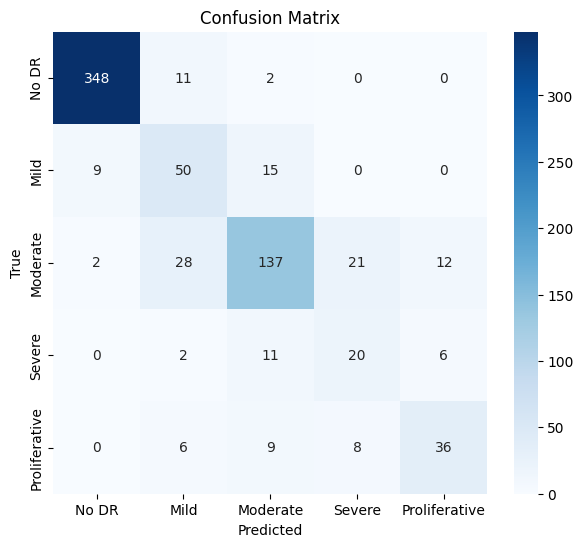

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_targets, val_preds)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

plt.figure(figsize=(7,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(val_targets, val_preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       361
           1       0.52      0.68      0.58        74
           2       0.79      0.69      0.73       200
           3       0.41      0.51      0.45        39
           4       0.67      0.61      0.64        59

    accuracy                           0.81       733
   macro avg       0.67      0.69      0.68       733
weighted avg       0.82      0.81      0.81       733



In [33]:
print("Prediction distribution:")
print(np.bincount(val_preds))

Prediction distribution:
[359  97 174  49  54]


In [34]:
print("True distribution:")
print(np.bincount(val_targets))

True distribution:
[361  74 200  39  59]


### The model achieves strong performance on the majority class (0), while showing weaker precision and recall on minority classes, highlighting the impact of class imbalance despite overall good accuracy (~77%).

## ⚡ EfficientNet-B4

In [35]:
import torchvision.models as models

model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 5)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 209MB/s]


### Freeze backbone

In [36]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [37]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(      
    model.classifier.parameters(),
    lr=1e-3,   # lr for head
    weight_decay=1e-4
)

### train head

In [38]:
EPOCHS = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_preds = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)

    # STORE METRICS

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/5
Train Loss: 1.4666 | Train Acc: 0.5241
Val Loss: 1.3104 | Val Acc: 0.7394
----------------------------------------
Epoch 2/5
Train Loss: 1.3055 | Train Acc: 0.6422
Val Loss: 1.2130 | Val Acc: 0.6753
----------------------------------------
Epoch 3/5
Train Loss: 1.2297 | Train Acc: 0.6405
Val Loss: 1.1349 | Val Acc: 0.6999
----------------------------------------
Epoch 4/5
Train Loss: 1.1892 | Train Acc: 0.6470
Val Loss: 1.0962 | Val Acc: 0.7394
----------------------------------------
Epoch 5/5
Train Loss: 1.1540 | Train Acc: 0.6487
Val Loss: 1.0842 | Val Acc: 0.7108
----------------------------------------


### Unfreeze last 4 blocks + head.

In [39]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-4:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

### The model is partially fine-tuned by unfreezing the last **4 blocks** of the EfficientNet feature extractor along with the **classifier head**, while keeping earlier layers frozen.

In [40]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30 #10
)

### The optimizer fine-tunes only unfrozen layers using **AdamW** with a lower learning rate, while a **CosineAnnealingLR scheduler** smoothly adjusts the learning rate for better convergence.

In [41]:
best_qwk = 0
patience = 6
counter = 0

In [42]:
EPOCHS = 15

train_losses = []
val_losses = []

train_accs = []
val_accs = []

train_qwks = []
val_qwks = []

for epoch in range(EPOCHS):

    # ======================
    # TRAIN
    # ======================
    model.train()

    train_loss = 0
    train_preds = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_targets, train_preds)
    train_qwk = compute_qwk(train_targets, train_preds)

    # ======================
    # VALIDATION
    # ======================

    model.eval()

    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_targets, val_preds)
    val_qwk = compute_qwk(val_targets, val_preds)

    # scheduler step
    scheduler.step()

    # ======================
    # STORE METRICS
    # ======================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_qwks.append(train_qwk)
    val_qwks.append(val_qwk)

    # ======================
    # SAVE BEST MODEL
    # ======================

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "/kaggle/working/best_effb4.pth")
        counter = 0
    else:
        counter += 1

    # ======================
    # PRINT
    # ======================

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train QWK: {train_qwk:.4f}")

    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   QWK: {val_qwk:.4f}")

    print("-"*50)

    # ======================
    # EARLY STOPPING
    # ======================

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1/15
Train Loss: 1.0792 | Train Acc: 0.6712 | Train QWK: 0.7439
Val   Loss: 0.9968 | Val   Acc: 0.7176 | Val   QWK: 0.8313
--------------------------------------------------
Epoch 2/15
Train Loss: 1.0132 | Train Acc: 0.6729 | Train QWK: 0.7740
Val   Loss: 0.9441 | Val   Acc: 0.7258 | Val   QWK: 0.8377
--------------------------------------------------
Epoch 3/15
Train Loss: 0.9488 | Train Acc: 0.7166 | Train QWK: 0.7990
Val   Loss: 0.9294 | Val   Acc: 0.7408 | Val   QWK: 0.8563
--------------------------------------------------
Epoch 4/15
Train Loss: 0.9206 | Train Acc: 0.7224 | Train QWK: 0.8023
Val   Loss: 0.9248 | Val   Acc: 0.7544 | Val   QWK: 0.8579
--------------------------------------------------
Epoch 5/15
Train Loss: 0.9223 | Train Acc: 0.7095 | Train QWK: 0.7997
Val   Loss: 0.9014 | Val   Acc: 0.7667 | Val   QWK: 0.8642
--------------------------------------------------
Epoch 6/15
Train Loss: 0.8920 | Train Acc: 0.7327 | Train QWK: 0.8222
Val   Loss: 0.8879 | Val   Acc

## ⚖️ Threshold Optimization

In [43]:
val_preds = []
val_targets = []

model.eval()

with torch.no_grad():
    
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        score = (probs * torch.arange(5, device=probs.device)).sum(dim=1)

        val_preds.extend(score.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

In [44]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import cohen_kappa_score


def apply_thresholds(preds, thresholds):

    thresholds = sorted(thresholds)

    return np.digitize(preds, thresholds)


def qwk_loss(thresholds, preds, targets):

    preds_class = apply_thresholds(preds, thresholds)

    return -cohen_kappa_score(targets, preds_class, weights="quadratic")


def optimize_thresholds(preds, targets):

    preds = np.array(preds)
    targets = np.array(targets)

    initial_thresholds = [0.5, 1.5, 2.5, 3.5]

    result = minimize(
        qwk_loss,
        initial_thresholds,
        args=(preds, targets),
        method="nelder-mead"
    )

    return result.x

In [45]:
val_preds_continuous = np.array(val_preds)
val_targets_array = np.array(val_targets)

best_thresholds = optimize_thresholds(
    val_preds_continuous,
    val_targets_array
)

print("Optimized thresholds:", best_thresholds)

Optimized thresholds: [0.52581683 1.34791843 2.75039631 3.41639011]


In [46]:
final_preds = apply_thresholds(
    val_preds_continuous,
    best_thresholds
)

qwk = cohen_kappa_score(
    val_targets_array,
    final_preds,
    weights="quadratic"
)

print("QWK after optimization:", qwk)

QWK after optimization: 0.8953489649113173


### Instead of direct class predictions, model outputs are treated as continuous severity scores and optimal thresholds are learned using optimization to maximize **QWK**, significantly improving performance without retraining.

In [47]:
torch.save(model.state_dict(), "/kaggle/working/efficientnet_b4_best.pth")

## 🔄 Test Time Augmentation

In [48]:
def predict_with_tta(model, loader, device):

    model.eval()

    all_preds = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            # original
            logits1 = model(images)

            # horizontal flip
            logits2 = model(torch.flip(images, dims=[3]))

            # vertical flip
            logits3 = model(torch.flip(images, dims=[2]))

            # average logits
            logits = (logits1 + logits2 + logits3) / 3

            probs = torch.softmax(logits, dim=1)

            score = (probs * torch.arange(5, device=device)).sum(dim=1)

            all_preds.extend(score.cpu().numpy())

    return np.array(all_preds)

In [49]:
val_preds_tta = predict_with_tta(model, val_loader, device)

In [50]:
final_preds = apply_thresholds(val_preds_tta, best_thresholds)

qwk = cohen_kappa_score(val_targets_array, final_preds, weights="quadratic")

print("QWK with TTA:", qwk)

QWK with TTA: 0.8924211775666345


### Test Time Augmentation (TTA) is applied by averaging predictions from original, horizontally flipped, and vertically flipped images, producing more stable outputs and improving QWK.

## 🔬 ensemble ResNet + EfficientNet

In [51]:
import torchvision.models as models
import torch.nn as nn
import torch

resnet = models.resnet50(weights=None) # to load trained weights, not ImageNet weights.

num_features = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 5)
)

resnet = resnet.to(device)

In [52]:
resnet.load_state_dict(
    torch.load("/kaggle/input/models/vabdoamr/resnet/pytorch/default/1/best_model(ResNet).pth")
)

resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [53]:
def get_model_scores(model, images, device):

    logits = model(images)

    probs = torch.softmax(logits, dim=1)

    scores = (probs * torch.arange(5, device=device)).sum(dim=1)

    return scores

In [54]:
def ensemble_predict_tta(resnet, effnet, loader, device):

    resnet.eval()
    effnet.eval()

    all_scores = []
    all_targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            # ORIGINAL
            score1_r = get_model_scores(resnet, images, device)
            score1_e = get_model_scores(effnet, images, device)

            # HORIZONTAL FLIP
            images_h = torch.flip(images, dims=[3])

            score2_r = get_model_scores(resnet, images_h, device)
            score2_e = get_model_scores(effnet, images_h, device)

            # VERTICAL FLIP
            images_v = torch.flip(images, dims=[2])

            score3_r = get_model_scores(resnet, images_v, device)
            score3_e = get_model_scores(effnet, images_v, device)

            # AVERAGE TTA FOR EACH MODEL
            resnet_score = (score1_r + score2_r + score3_r) / 3
            effnet_score = (score1_e + score2_e + score3_e) / 3

            # ENSEMBLE MODELS
            final_score = (resnet_score + effnet_score) / 2

            all_scores.extend(final_score.cpu().numpy())
            all_targets.extend(labels.numpy())

    return np.array(all_scores), np.array(all_targets)

### Predictions from ResNet50 and EfficientNet-B4 are combined using both **TTA** and **model ensembling**, where each model’s augmented predictions are averaged first, then merged via score averaging to produce more robust final predictions.

In [55]:
scores, targets = ensemble_predict_tta(
    resnet,
    model,      # EfficientNet model
    val_loader,
    device
)

In [56]:
best_thresholds = optimize_thresholds(scores, targets)

print("Optimized thresholds:", best_thresholds)

Optimized thresholds: [0.52923868 1.40708451 2.67470493 3.34681216]


In [57]:
final_preds = apply_thresholds(scores, best_thresholds)

In [58]:
from sklearn.metrics import cohen_kappa_score

qwk = cohen_kappa_score(
    targets,
    final_preds,
    weights="quadratic"
)

print("Ensemble QWK:", qwk)

Ensemble QWK: 0.898045963764689


### The final ensemble achieves a strong **QWK of 0.8989**, demonstrating the effectiveness of combining models and prediction strategies.